# Chapter 57 — Attention Score Tables

## Learning goals

Chapter 56 computed a complete unscaled causal-attention step from queries, keys, and values.

This chapter zooms in on the score table so its axes, shapes, and matrix multiplication become unambiguous.

By the end of this chapter, you should be able to:

- Define an attention score table as all pairwise query-key dot products.
- Interpret rows as receiving query positions and columns as source key positions.
- Compute the table with explicit loops.
- Compute the same table with `query_vectors @ key_vectors.transpose(-2, -1)`.
- Explain why the key tensor's final two dimensions are transposed.
- Print and interpret labeled rows, columns, and individual entries.
- Explain why the table need not be symmetric.
- Detect the semantic bug caused by reversing queries and keys.
- Plot an annotated raw-score heatmap.
- Extend the formula across a leading batch dimension.
- Distinguish raw or scaled scores from normalized attention weights.

## The big idea

Attention compares every receiving query with every source key.

Entry `[i, j]` is:

```text
query from receiving position i · key from source position j
```

For `C_q` query positions and `C_k` key positions, the score table has shape `[C_q, C_k]`.

Self-attention uses the same sequence for both sides, so `C_q = C_k = C` and the table is square.

A raw score measures query-key compatibility before scaling, masking, and softmax rather than directly specifying an attention amount.

## Terms used in this chapter

- A **receiving position** supplies a query and will eventually receive an output.
- A **source position** supplies a key for matching and a value for later mixing.
- An **attention score** is a raw query-key dot product.
- An **attention score table** contains one score for every query-key position pair.
- A **row** contains one receiving query position's scores against every source key.
- A **column** contains every receiving query position's score against one source key.
- A **transpose** swaps selected tensor dimensions.
- A **heatmap** represents numeric values using color.
- A **scaled score** is a raw score divided by a chosen scale factor.
- An **attention weight** is a later normalized coefficient over allowed source positions.

## Define queries and keys for four positions

Use the sequence `the small dog barked` and hand-written three-dimensional vectors.

A trained model would produce these vectors with learned projections, but fixed numbers make every score reproducible.

In [1]:
import torch

device = "cpu"
tokens = ["the", "small", "dog", "barked"]
query_vectors = torch.tensor(
    [
        [1.0, 0.0, 0.0],
        [0.5, 0.5, 0.0],
        [0.0, 1.0, 0.5],
        [0.0, 0.5, 1.0],
    ],
    dtype=torch.float32,
    device=device,
)
key_vectors = torch.tensor(
    [
        [1.0, 0.0, 0.0],
        [0.0, 1.0, 0.0],
        [0.0, 1.0, 1.0],
        [0.0, 0.0, 1.0],
    ],
    dtype=torch.float32,
    device=device,
)

print("device:", device)
print("query shape:", query_vectors.shape)
print("key shape:", key_vectors.shape)
print()
print("position | token  | query           | key")
print("-" * 59)
for position, token in enumerate(tokens):
    print(
        f"{position:>8} | "
        f"{token:>6} | "
        f"{str(query_vectors[position].tolist()):>15} | "
        f"{key_vectors[position].tolist()}"
    )

device: cpu
query shape: torch.Size([4, 3])
key shape: torch.Size([4, 3])

position | token  | query           | key
-----------------------------------------------------------
       0 |    the | [1.0, 0.0, 0.0] | [1.0, 0.0, 0.0]
       1 |  small | [0.5, 0.5, 0.0] | [0.0, 1.0, 0.0]
       2 |    dog | [0.0, 1.0, 0.5] | [0.0, 1.0, 1.0]
       3 | barked | [0.0, 0.5, 1.0] | [0.0, 0.0, 1.0]


Both tensors have shape `[4, 3]`, so every query row can be dotted with every key row.

The vectors at one token position differ because queries and keys have different matching roles.

## Compute one table entry by hand

Use row 3 and column 2 to match the `barked` query against the `dog` key.

In [2]:
receiving_position = 3
source_position = 2
query_vector = query_vectors[receiving_position]
key_vector = key_vectors[source_position]
manual_score = 0.0

print("component | query | key   | product")
print("-" * 39)
for component in range(query_vector.shape[0]):
    query_component = query_vector[component].item()
    key_component = key_vector[component].item()
    product = query_component * key_component
    manual_score += product
    print(
        f"{component:>9} | "
        f"{query_component:>5.2f} | "
        f"{key_component:>5.2f} | "
        f"{product:>7.2f}"
    )

torch_score = torch.dot(query_vector, key_vector).item()
print("-" * 39)
print("manual score:", manual_score)
print("torch.dot score:", torch_score)
print("entry meaning: 'barked' query matched with 'dog' key")

component | query | key   | product
---------------------------------------
        0 |  0.00 |  0.00 |    0.00
        1 |  0.50 |  1.00 |    0.50
        2 |  1.00 |  1.00 |    1.00
---------------------------------------
manual score: 1.5
torch.dot score: 1.5
entry meaning: 'barked' query matched with 'dog' key


The score is `1.5`, and it belongs at table entry `[3, 2]`.

Entry `[2, 3]` asks the reverse question and need not have the same value.

## Compute all entries with loops

Make the two axes explicit by looping over receiving query positions outside and source key positions inside.

Stacking scalar scores retains PyTorch's autograd connections, although the loop remains inefficient for real models.

In [3]:
def compute_attention_scores_with_loops(
    query_vectors: torch.Tensor,
    key_vectors: torch.Tensor,
) -> torch.Tensor:
    if query_vectors.ndim != 2 or key_vectors.ndim != 2:
        raise ValueError("Queries and keys must both be two-dimensional.")
    if query_vectors.shape[1] != key_vectors.shape[1]:
        raise ValueError("Query and key vector dimensions must match.")
    if query_vectors.shape[0] < 1 or key_vectors.shape[0] < 1:
        raise ValueError("Queries and keys must each contain at least one position.")
    if query_vectors.device != key_vectors.device:
        raise ValueError("Queries and keys must use the same device.")

    score_rows: list[torch.Tensor] = []
    for query_position in range(query_vectors.shape[0]):
        row_scores: list[torch.Tensor] = []
        for key_position in range(key_vectors.shape[0]):
            row_scores.append(
                torch.dot(
                    query_vectors[query_position],
                    key_vectors[key_position],
                )
            )
        score_rows.append(torch.stack(row_scores))

    return torch.stack(score_rows)


loop_scores = compute_attention_scores_with_loops(
    query_vectors,
    key_vectors,
)

print("loop score table:")
print(loop_scores)
print("shape:", loop_scores.shape)

loop score table:
tensor([[1.0000, 0.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.5000, 0.0000],
        [0.0000, 1.0000, 1.5000, 0.5000],
        [0.0000, 0.5000, 1.5000, 1.0000]])
shape: torch.Size([4, 4])


The outer loop creates rows, and the inner loop moves across source-key columns.

The resulting `[4, 4]` table contains all 16 pairwise scores.

## Print the table with semantic axis labels

A labeled helper makes the row and column roles visible rather than relying on tensor indexes alone.

In [4]:
def print_score_table(
    score_table: torch.Tensor,
    query_tokens: list[str],
    key_tokens: list[str],
    title: str,
) -> None:
    if score_table.ndim != 2:
        raise ValueError("score_table must be two-dimensional.")
    if score_table.shape != (len(query_tokens), len(key_tokens)):
        raise ValueError("Token labels must match the two table dimensions.")

    print(title)
    print("-" * len(title))
    header = "query \ key".rjust(14)
    for token in key_tokens:
        header += f" | {token:>8}"
    print(header)
    print("-" * len(header))

    for query_position, query_token in enumerate(query_tokens):
        row_text = f"{query_token:>14}"
        for key_position in range(len(key_tokens)):
            score = score_table[query_position, key_position].item()
            row_text += f" | {score:>8.3f}"
        print(row_text)


print_score_table(
    loop_scores,
    query_tokens=tokens,
    key_tokens=tokens,
    title="Loop-computed attention score table",
)

Loop-computed attention score table
-----------------------------------
   query \ key |      the |    small |      dog |   barked
----------------------------------------------------------
           the |    1.000 |    0.000 |    0.000 |    0.000
         small |    0.500 |    0.500 |    0.500 |    0.000
           dog |    0.000 |    1.000 |    1.500 |    0.500
        barked |    0.000 |    0.500 |    1.500 |    1.000


Read across the `barked` row to compare one receiving query with all source keys.

Read down the `dog` column to compare all receiving queries with one source key.

## Interpret one row and one column

Print both views explicitly to reinforce that they answer different matching questions.

In [5]:
barked_position = tokens.index("barked")
dog_position = tokens.index("dog")

print("Row: 'barked' query matched against every key")
print("-" * 52)
for key_position, key_token in enumerate(tokens):
    print(
        f"query('barked') · key({key_token!r}): "
        f"{loop_scores[barked_position, key_position].item():.3f}"
    )

print()
print("Column: every query matched against the 'dog' key")
print("-" * 55)
for query_position, query_token in enumerate(tokens):
    print(
        f"query({query_token!r}) · key('dog'): "
        f"{loop_scores[query_position, dog_position].item():.3f}"
    )

Row: 'barked' query matched against every key
----------------------------------------------------
query('barked') · key('the'): 0.000
query('barked') · key('small'): 0.500
query('barked') · key('dog'): 1.500
query('barked') · key('barked'): 1.000

Column: every query matched against the 'dog' key
-------------------------------------------------------
query('the') · key('dog'): 0.000
query('small') · key('dog'): 0.500
query('dog') · key('dog'): 1.500
query('barked') · key('dog'): 1.500


A row will later be scaled, masked, and normalized across its columns to create one receiving position's attention distribution.

A column is not normalized independently for ordinary self-attention.

## Compute the table with matrix multiplication

Transpose keys from `[C_k, D_qk]` to `[D_qk, C_k]` so each query row dots with every key column.

In [6]:
transposed_keys = key_vectors.transpose(-2, -1)
matrix_scores = query_vectors @ transposed_keys

print("query shape:", query_vectors.shape)
print("key shape:", key_vectors.shape)
print("transposed key shape:", transposed_keys.shape)
print("score shape:", matrix_scores.shape)
print("matrix scores:")
print(matrix_scores)
print("loop and matrix tables match:", torch.allclose(loop_scores, matrix_scores))

query shape: torch.Size([4, 3])
key shape: torch.Size([4, 3])
transposed key shape: torch.Size([3, 4])
score shape: torch.Size([4, 4])
matrix scores:
tensor([[1.0000, 0.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.5000, 0.0000],
        [0.0000, 1.0000, 1.5000, 0.5000],
        [0.0000, 0.5000, 1.5000, 1.0000]])
loop and matrix tables match: True


The compact formula is:

```python
attention_scores = query_vectors @ key_vectors.transpose(-2, -1)
```

It performs the same component multiplications and additions as the nested loops.

Using `transpose(-2, -1)` instead of `.T` makes the intended last-two-dimension swap work when leading batch dimensions are added.

## Reversing queries and keys is a semantic bug

The tempting expression `K @ Qᵀ` still returns a square `[4, 4]` tensor for self-attention.

Its rows are key positions rather than receiving query positions, so the expected attention axes have been reversed.

In [7]:
reversed_scores = key_vectors @ query_vectors.transpose(-2, -1)

print("correct score at [barked, dog]:", matrix_scores[3, 2].item())
print("reverse-direction score at [dog, barked]:", matrix_scores[2, 3].item())
print("reversed multiplication at [barked, dog]:", reversed_scores[3, 2].item())
print("reversed shape still looks valid:", reversed_scores.shape)
print(
    "reversed table equals correct transpose:",
    torch.allclose(reversed_scores, matrix_scores.T),
)
print(
    "correct table is symmetric:",
    torch.allclose(matrix_scores, matrix_scores.T),
)

correct score at [barked, dog]: 1.5
reverse-direction score at [dog, barked]: 0.5
reversed multiplication at [barked, dog]: 0.5
reversed shape still looks valid: torch.Size([4, 4])
reversed table equals correct transpose: True
correct table is symmetric: False


The correct table is not symmetric because query and key vectors play different directional roles.

A shape check alone cannot detect the reversed-multiplication bug.

## Plot an annotated raw-score heatmap

Keep the same semantic labels on the plot axes and write each raw score inside its cell.

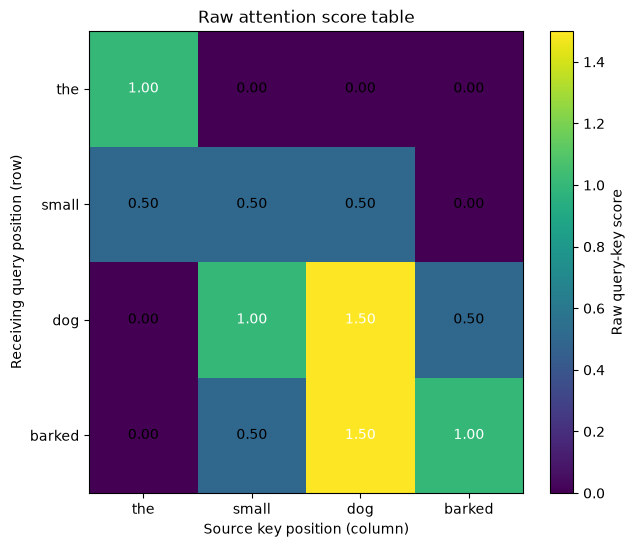

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))
plt.imshow(matrix_scores, aspect="auto")
plt.colorbar(label="Raw query-key score")
plt.xticks(range(len(tokens)), tokens)
plt.yticks(range(len(tokens)), tokens)
plt.xlabel("Source key position (column)")
plt.ylabel("Receiving query position (row)")
plt.title("Raw attention score table")

color_threshold = (matrix_scores.min() + matrix_scores.max()) / 2
for row in range(len(tokens)):
    for column in range(len(tokens)):
        plt.text(
            column,
            row,
            f"{matrix_scores[row, column].item():.2f}",
            ha="center",
            va="center",
            color="white" if matrix_scores[row, column] > color_threshold else "black",
        )

plt.show()

The heatmap changes only the display, not the row-column meaning.

The color at row `barked`, column `dog` represents `query('barked') · key('dog') = 1.5`.

## Raw scores are not attention weights

Raw score rows may contain any finite real values and do not need to sum to one.

Print this example's row sums, then create the scaled table previewed by Chapter 56.

In [9]:
query_key_dimension = query_vectors.shape[-1]
scale = query_key_dimension**0.5
scaled_scores = matrix_scores / scale
raw_ranking = torch.argsort(matrix_scores, dim=1)
scaled_ranking = torch.argsort(scaled_scores, dim=1)

print("raw row sums:", matrix_scores.sum(dim=1))
print("raw scores:")
print(matrix_scores)
print("scale factor:", scale)
print("scaled scores:")
print(scaled_scores)
print(
    "scaled scores preserve ranking within each row:",
    bool(torch.all(raw_ranking == scaled_ranking)),
)

raw row sums: tensor([1.0000, 1.5000, 3.0000, 3.0000])
raw scores:
tensor([[1.0000, 0.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.5000, 0.0000],
        [0.0000, 1.0000, 1.5000, 0.5000],
        [0.0000, 0.5000, 1.5000, 1.0000]])
scale factor: 1.7320508075688772
scaled scores:
tensor([[0.5774, 0.0000, 0.0000, 0.0000],
        [0.2887, 0.2887, 0.2887, 0.0000],
        [0.0000, 0.5774, 0.8660, 0.2887],
        [0.0000, 0.2887, 0.8660, 0.5774]])
scaled scores preserve ranking within each row: True


Scaling changes score magnitude without changing axes or within-row ranking because the same positive factor divides every entry.

Scaled scores still are not weights because causal masking and row-wise softmax remain to be applied.

## Preserve the last two axes in a batch

Stack two query/key sets and apply exactly the same transpose expression.

Make the second query set half as large so the two batch score tables are visibly independent.

In [10]:
batched_queries = torch.stack([query_vectors, 0.5 * query_vectors])
batched_keys = torch.stack([key_vectors, key_vectors])
batched_scores = batched_queries @ batched_keys.transpose(-2, -1)

print("batched query shape:", batched_queries.shape)
print("batched key shape:", batched_keys.shape)
print("transposed key shape:", batched_keys.transpose(-2, -1).shape)
print("batched score shape:", batched_scores.shape)
print(
    "batch item 0 matches the original:",
    torch.allclose(
        batched_scores[0],
        matrix_scores,
    ),
)
print(
    "batch item 1 is half the original:",
    torch.allclose(
        batched_scores[1],
        0.5 * matrix_scores,
    ),
)

batched query shape: torch.Size([2, 4, 3])
batched key shape: torch.Size([2, 4, 3])
transposed key shape: torch.Size([2, 3, 4])
batched score shape: torch.Size([2, 4, 4])
batch item 0 matches the original: True
batch item 1 is half the original: True


The batched result has shape `[B, C_q, C_k] = [2, 4, 4]`.

`transpose(-2, -1)` swaps only key position and vector dimensions while preserving the leading batch dimension.

## Shape summary

For unbatched query positions `C_q`, key positions `C_k`, and shared query-key dimension `D_qk`:

```text
queries:        [C_q, D_qk]
keys:           [C_k, D_qk]
transposed keys:[D_qk, C_k]
scores:         [C_q, C_k]
```

With batch size `B`:

```text
queries:        [B, C_q, D_qk]
keys:           [B, C_k, D_qk]
transposed keys:[B, D_qk, C_k]
scores:         [B, C_q, C_k]
```

## Common mistakes

- Do not describe a raw compatibility score as the final amount of attention.
- Do not forget that rows are receiving queries and columns are source keys.
- Do not treat `[i, j]` and `[j, i]` as interchangeable.
- Do not assume a self-attention score table is symmetric.
- Do not reverse `Q @ Kᵀ` merely because `K @ Qᵀ` has the same square shape.
- Do not transpose leading batch dimensions.
- Do not interpret raw or scaled score row sums as probabilities.
- Do not use Python loops in a real attention implementation when matrix multiplication expresses the same work.

## Takeaways

An attention score table contains every receiving-query to source-key dot product.

Its axis contract is:

```text
row i    = receiving query position i
column j = source key position j
entry ij = query[i] · key[j]
```

Nested loops make that meaning explicit, while `Q @ K.transpose(-2, -1)` computes the same table efficiently.

The table may be rectangular, is not generally symmetric, and retains its last-two-axis meaning inside a batch.

Raw or scaled scores still require masking and row-wise softmax before they become attention weights.

## What comes next

The next chapter prepares each score row with causal masking and converts allowed scores into attention weights with softmax.

That gives every receiving query position a normalized distribution over the source key positions it may use.